# TEST: ripulire gli spettri LOCK-IN con un autoencoder

### Lettura dati

In [1]:
import numpy as np

# 1. Caricamento dati
f = np.arange(2500, 3250)
s_clean = np.load('../data/X_spectra_50k.npy')
B = np.load('../data/Y_B_field_50k.npy')

input_shape = s_clean.shape[1]

### Noising

In [2]:
from ml_odmr.noising import *

N_spettri = s_clean.shape[0]
N_punti = s_clean.shape[1]

# 2. Aggiunta rumore
s_noisy = np.zeros_like(s_clean)
ds_dx = np.zeros_like(s_clean)
ds_dx_noisy = np.zeros_like(s_clean)

for i in range(N_spettri):
    # sporco il segnale originale
    s_noisy[i] = add_poisson_noise(s_clean[i], scale=0.05)
    s_noisy[i] = add_poly_trend(f, s_noisy[i], scale=0.5)
    
    # calcolo la derivata numerica del segnale pulito
    ds_dx[i] = np.gradient(s_clean[i], f)
    # calcolo la derivata numerica del segnale sporco
    ds_dx_noisy[i] = np.gradient(s_noisy[i], f)
    # inverto la metà destra delle derivate
    for j in range(N_punti//2, N_punti):
        ds_dx[i][j] = -ds_dx[i][j]
        ds_dx_noisy[i][j] = -ds_dx_noisy[i][j]

### Scaling

Provo a scalare gli spettri. Ho già visto che Standard e MinMax non funzionano molto bene.

In [3]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
ds_dx_noisy_scaled = scaler.fit_transform(ds_dx_noisy)
ds_dx_scaled = scaler.transform(ds_dx)

### Modello

In [4]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Input
from tensorflow.keras.constraints import max_norm # per il max-norm constraint

In [5]:
# 3. Costruzione del Modello
model = Sequential()

# ENCODER #
model.add(Input(shape=(input_shape,)))
model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Bottleneck layer con max-norm constraint (es. valore max 3) #
model.add(Dense(8, name='bottleneck', kernel_constraint=max_norm(3)))
model.add(BatchNormalization())
model.add(Activation('relu'))

# DECODER #
model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(input_shape))
model.add(Activation('linear')) # Linear è corretto per la regressione dei bin

# Compilazione
model.compile(optimizer='adam', loss='mean_absolute_error')#'mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        48,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 750)            │        48,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 750)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,358 (399.84 KB)

 Trainable params: 101,958 (398.27 KB)

 Non-trainable params: 400 (1.56 KB)

In [6]:
# 4. Fit del modello (Denoising)
# x = input rumoroso, y = target pulito
history = model.fit(
    x=ds_dx_noisy_scaled, 
    y=ds_dx_scaled, 
    epochs=50,          # Sostituisci con il tuo no_epochs
    batch_size=32,      # Sostituisci con il tuo batch_size
    validation_split=0.2 # Usa il 20% dei dati per testare l'overfitting
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.0964 - val_loss: 1.9821
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.9845 - val_loss: 1.8337
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.8895 - val_loss: 1.7186
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.8244 - val_loss: 1.6506
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7765 - val_loss: 1.5993
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7307 - val_loss: 1.5398
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6883 - val_loss: 1.5097
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6493 - val_loss: 1.4729
Epoch 9/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6140 - val_loss: 1.4305
Epoch 10/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5864 - val_loss: 1.3971
Epoch 11/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5512 - val_loss: 1.3702
Epoch 12/50
1250/1250 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


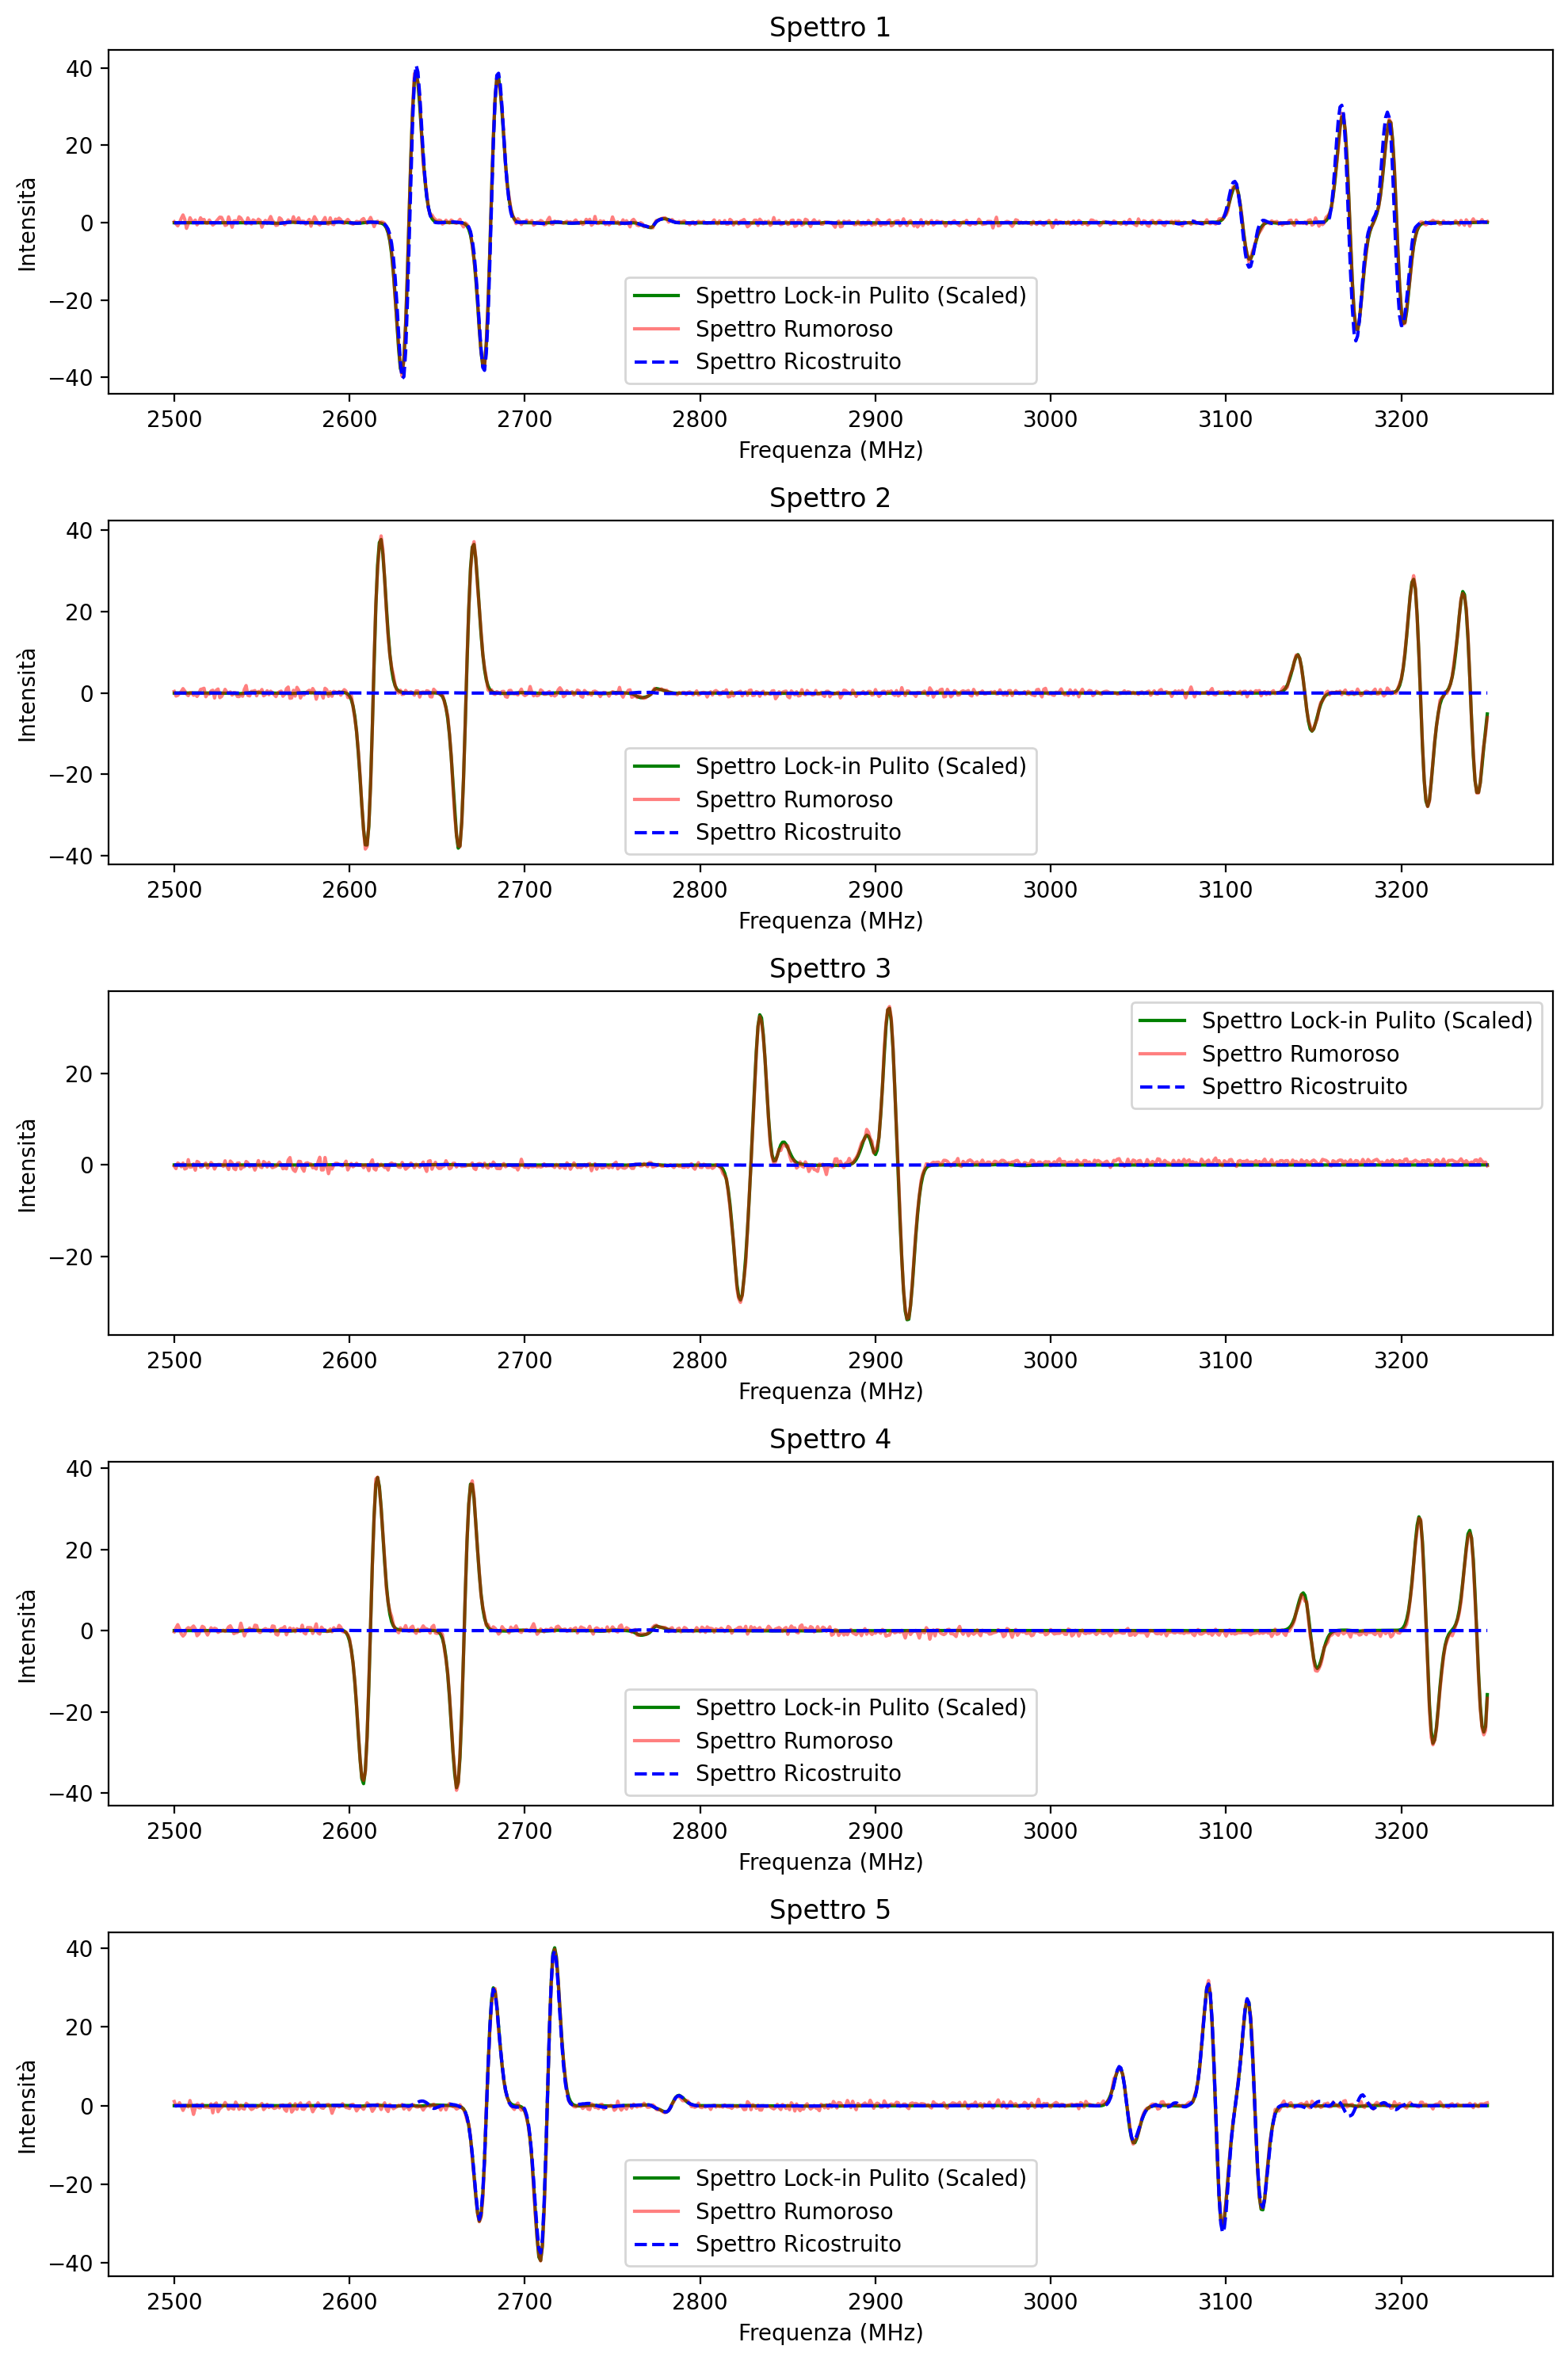

In [7]:
# 5. Ricostruzione (Previsione)
# Simuliamo di voler pulire i primi 5 spettri del nostro dataset
spettri_da_pulire = ds_dx_noisy_scaled[:5]
spettri_ricostruiti = model.predict(spettri_da_pulire)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 15), dpi=200)
for i in range(5):
    plt.subplot(5, 1, i+1)
    plt.plot(f, ds_dx_scaled[i], label='Spettro Lock-in Pulito (Scaled)', color='green')
    plt.plot(f, spettri_da_pulire[i], label='Spettro Rumoroso', color='red', alpha=0.5)
    plt.plot(f, spettri_ricostruiti[i], label='Spettro Ricostruito', color='blue', linestyle='dashed')
    plt.legend()
    plt.title(f'Spettro {i+1}')
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
plt.tight_layout()
plt.show()

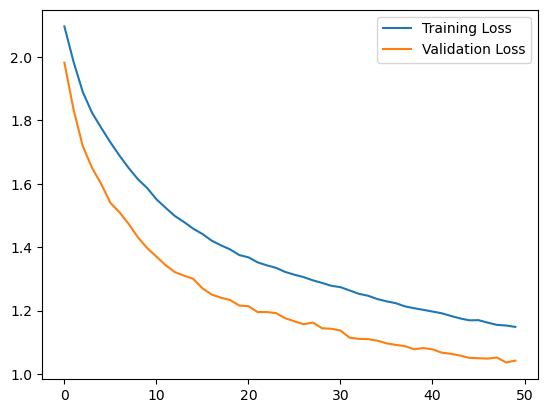

In [8]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()